# Optimizing LLM context for clinical-guideline evaluation

**AIIJC · Sber Health Industry Center case.** Before an LLM checks a patient
against a clinical guideline, this pipeline removes the *Treatment*
subsections that cannot apply to the patient, so the LLM reads fewer tokens and
less irrelevant text.

| | Task | Metric | Final model | Validation | Leaderboard |
|---|---|---|---|---|---|
| **Stage 1** | title → General (0) / Special (1) | macro-F0.5 → M1 | lemmatised word + char TF-IDF + condition markers → logistic regression (C = 10, threshold 0.69) + Stage-2-title rule | nested 5-fold M1 = **0.843** | M1 = 0.922 |
| **Stage 2** | (title, protocol) → Not applicable (0) / Applicable (1) | macro-F2 → M2 | field extraction + lemmatised TF-IDF + demographics + **11 contradiction / unknown features** → logistic regression (threshold 0.5) | 5-fold M2 = **0.702** (5×5 repeated: 0.699 ± 0.007) | M2 = 0.731 |
| **Total** | `70 · (0.3·M1 + 0.7·M2)` | | | | **55.168** |

**How to run.** Open the notebook in Colab or Jupyter and choose
*Runtime → Run all*; no edits are needed.
* The first cell installs the pinned libraries.
* The data cell uses `train_stage1.csv`, `test_stage1.csv`, `train_stage2.csv`
  and `test_stage2.csv` if they sit next to the notebook. Otherwise it downloads
  them from the project's public GitHub repository and checks their SHA-256.
* No GPU is needed. With all switches on, the run takes about 1.5 minutes on a
  6-core laptop, and a few minutes on a Colab CPU.

**Output.** `outputs/submission.csv`. The notebook stops unless the file is
byte-identical to the one submitted to the platform (leaderboard 55.168).
`SEED = 42` fixes every random step.

**Contents**
0. Setup and reproducibility
1. Data
2. Competition metric
3. Exploratory analysis
4. Russian medical text processing
5. Stage 1: General vs Special
6. Stage 2: applicability as condition matching
7. Submission and reproducibility check
8. Results, architecture choice, limitations

## 0. Setup and reproducibility

Only three packages are pinned: they are the ones that decide the predictions.
* `scikit-learn` fixes the solvers and vectorisers.
* `pymorphy3` and its dictionary fix the lemmas.

numpy, scipy and pandas are left at the runtime's versions, so Colab needs no
kernel restart. The final model is two linear models, so it uses no PyTorch or
CUDA, and there is no GPU nondeterminism to control.

In [1]:
# 0.1 Install the pinned packages (a no-op when they are already present)
import subprocess
import sys
from importlib.metadata import PackageNotFoundError, version

PINNED = {
    "scikit-learn": "1.9.0",
    "pymorphy3": "2.0.6",
    "pymorphy3-dicts-ru": "2.4.417150.4580142",
}


def installed_version(dist):
    try:
        return version(dist)
    except PackageNotFoundError:
        return None


to_install = [f"{d}=={v}" for d, v in PINNED.items() if installed_version(d) != v]
if to_install:
    print("installing:", *to_install)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *to_install])
print({d: installed_version(d) for d in PINNED})

{'scikit-learn': '1.9.0', 'pymorphy3': '2.0.6', 'pymorphy3-dicts-ru': '2.4.417150.4580142'}


In [2]:
# 0.2 Imports, seeds and run switches
import hashlib
import json
import os
import random
import re
import time
import warnings
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymorphy3
import scipy
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, fbeta_score, precision_recall_fscore_support, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# Python's string hashing is randomised per process. The pipeline never depends
# on set or dict-of-set iteration order (see 6.2), so no PYTHONHASHSEED is needed.

# Run switches. The defaults re-derive every selected hyperparameter from scratch.
RUN_STAGE1_SELECTION = True   # nested CV over C (the slowest step); False uses the recorded result
RUN_STAGE1_ABLATION = True    # feature-block ablation for Stage 1
RUN_STAGE2_REPEATED_CV = True # 5x5 repeated CV of the Stage 2 ablation

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
T_START = time.time()

ENV = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": scipy.__version__,
    "scikit-learn": sklearn.__version__,
    "pymorphy3": installed_version("pymorphy3"),
    "pymorphy3-dicts-ru": installed_version("pymorphy3-dicts-ru"),
    "seed": SEED,
}
print(json.dumps(ENV, indent=1))

{
 "python": "3.14.6",
 "numpy": "2.4.6",
 "pandas": "3.0.3",
 "scipy": "1.18.0",
 "scikit-learn": "1.9.0",
 "pymorphy3": "2.0.6",
 "pymorphy3-dicts-ru": "2.4.417150.4580142",
 "seed": 42
}


## 1. Data

**Encoding.** The first public copy of `train_stage1.csv` was a cp1252 export in
which every Cyrillic letter had been replaced by `?`. The copy re-downloaded
from the platform is clean UTF-8. The loader tries UTF-8 first and falls back
to cp1251, and a guard stops the run if it is given the damaged copy: the
Stage 1 model reads words, so it would silently degrade on that file.

In [3]:
# 1.1 Locate and load the competition files
DATA_FILES = ("train_stage1.csv", "test_stage1.csv", "train_stage2.csv", "test_stage2.csv")


# Public copy of the competition files (the clean UTF-8 train_stage1.csv),
# pinned by SHA-256 so a changed download cannot pass silently.
DATA_URL = "https://raw.githubusercontent.com/leshbs/llm-optimizer/main/"
DATA_SHA256 = {
    "train_stage1.csv": "61caf9ddc0683c238d07cdd6a058e540ee5188846df2da81dc395304ee96b91f",
    "test_stage1.csv": "69db5a0aa85c94d121611bbce05a9df6daac0cdffdc0c572c1df245af2dde320",
    "train_stage2.csv": "a567a5b3ed730678c5fd6fe1420ee62054f0c65624b504e0dc704f645c495895",
    "test_stage2.csv": "86025ee62a94ac59834044b521be6d3d313f811fcdb0446475c98bf5d8d3c149",
}


def sha256_of(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def locate_data_dir():
    # 1) files already next to the notebook (local run, or uploaded by hand)
    for cand in (Path("."), Path("data"), Path("/content")):
        if all((cand / f).exists() for f in DATA_FILES):
            return cand
    # 2) otherwise download them (the default in a fresh Colab runtime)
    from urllib.request import urlretrieve
    target = Path("data")
    target.mkdir(exist_ok=True)
    for name in DATA_FILES:
        path = target / name
        if not path.exists() or sha256_of(path) != DATA_SHA256[name]:
            print("downloading", name)
            urlretrieve(DATA_URL + name, path)
        assert sha256_of(path) == DATA_SHA256[name], f"{name}: checksum mismatch after download"
    return target


def read_competition_csv(path):
    # UTF-8 first; cp1251 is the encoding of the damaged Stage 1 export
    for encoding in ("utf-8", "cp1251"):
        try:
            return pd.read_csv(path, encoding=encoding)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"cannot decode {path}")


DATA_DIR = locate_data_dir()
train1 = read_competition_csv(DATA_DIR / "train_stage1.csv")
test1 = read_competition_csv(DATA_DIR / "test_stage1.csv")
train2 = read_competition_csv(DATA_DIR / "train_stage2.csv")
test2 = read_competition_csv(DATA_DIR / "test_stage2.csv")

assert train1.shape == (1767, 3) and test1.shape == (442, 2), "unexpected Stage 1 shape"
assert train2.shape == (690, 4) and test2.shape == (173, 3), "unexpected Stage 2 shape"
share_q = train1["title_text"].str.count(r"\?").sum() / train1["title_text"].str.len().sum()
assert share_q < 0.05, (
    f"{share_q:.0%} of train_stage1 characters are '?': this is the damaged export. "
    "Download the clean UTF-8 train_stage1.csv from the platform."
)
print("data directory:", DATA_DIR.resolve())
for name, df in (("train_stage1", train1), ("test_stage1", test1),
                 ("train_stage2", train2), ("test_stage2", test2)):
    same = sha256_of(DATA_DIR / f"{name}.csv") == DATA_SHA256[f"{name}.csv"]
    print(f"{name:13s} {df.shape}  file identical to the reference copy: {same}")
print(f"share of '?' in train_stage1 titles: {share_q:.4f}")

data directory: C:\Users\Lesharo Bladen S\Downloads\AIIJC
train_stage1  (1767, 3)  file identical to the reference copy: True
test_stage1   (442, 2)  file identical to the reference copy: True
train_stage2  (690, 4)  file identical to the reference copy: True
test_stage2   (173, 3)  file identical to the reference copy: True
share of '?' in train_stage1 titles: 0.0000


## 2. Competition metric

The platform formula, used for every validation number in this notebook:

* `M1 = clip((macro-F0.5 − 0.5) / 0.45, 0, 1)`
* `M2 = clip((macro-F2 − 0.5) / 0.45, 0, 1)`
* `points = 70 · (0.3·M1 + 0.7·M2)`

Two consequences guide the whole project:

* **One point of M2 is worth 2.3 points of M1.**
* **A trivial "always applicable" model scores M2 = 0**, because macro-F2
  averages both classes. So recall on "Applicable" cannot be bought by giving up
  the "Not applicable" class entirely.

In [4]:
# 2.1 Metric functions
def stage1_score(y_true, y_pred):
    f = fbeta_score(y_true, y_pred, beta=0.5, average="macro", zero_division=0)
    return float(np.clip((f - 0.5) / 0.45, 0.0, 1.0))


def stage2_score(y_true, y_pred):
    f = fbeta_score(y_true, y_pred, beta=2, average="macro", zero_division=0)
    return float(np.clip((f - 0.5) / 0.45, 0.0, 1.0))


def total_points(m1, m2):
    return 70 * (0.3 * m1 + 0.7 * m2)


y2_all = train2["label"].to_numpy()
print("Stage 2, always 'Applicable'    : M2 =", stage2_score(y2_all, np.ones_like(y2_all)))
print("Stage 1, always 'General'       : M1 =", stage1_score(train1["label"], np.zeros(len(train1), int)))
print("points per +0.01 M1 / +0.01 M2  :", round(total_points(0.01, 0), 3), "/", round(total_points(0, 0.01), 3))

Stage 2, always 'Applicable'    : M2 = 0.0
Stage 1, always 'General'       : M1 = 0.0
points per +0.01 M1 / +0.01 M2  : 0.21 / 0.49


## 3. Exploratory analysis

The questions that shaped the design:

* **Class balance.** How imbalanced is each stage?
* **Title structure.** What does a title's hierarchy look like, and does its
  depth relate to the label?
* **Protocol length.** How long are the protocols, and what makes them long?
* **Stage 2 label source.** How much of the Stage 2 label is decided by the
  title alone?

In [5]:
# 3.1 Class balance and title structure
def last_line(title):
    return str(title).strip().split("\n")[-1]


def heading_depth(title):
    line = last_line(title)
    return len(line) - len(line.lstrip("#"))


balance = pd.DataFrame({
    "Stage 1 (1 = Special)": train1["label"].value_counts(normalize=True),
    "Stage 2 (1 = Applicable)": train2["label"].value_counts(normalize=True),
}).round(3)
print(balance, "\n")

print("Stage 1 title example:\n" + train1["title_text"].iloc[0], "\n")
depth = train1["title_text"].map(heading_depth)
print("Special rate by heading depth of the subsection line:")
print(pd.crosstab(depth, train1["label"], normalize="index").round(3)
      .assign(n=depth.value_counts()).rename(columns={0: "General", 1: "Special"}))

       Stage 1 (1 = Special)  Stage 2 (1 = Applicable)
label                                                 
0                      0.783                     0.343
1                      0.217                     0.657 

Stage 1 title example:
Клинические рекомендации "Менопауза и климактерическое состояние у женщины"
Возрастная категория: Взрослые
# Лечение
## Негормональное лечение 

Special rate by heading depth of the subsection line:
label       General  Special     n
title_text                        
1             1.000    0.000    19
2             0.852    0.148  1415
3             0.480    0.520   333


In [6]:
# 3.2 Stage 2 protocols: length, structure, and where the length comes from
proto = pd.concat([train2["protocol_text"], test2["protocol_text"]]).astype(str)
lab_chars = proto.map(lambda t: sum(len(m) for m in re.findall(r"Показатель:[^\n]*", t)))
summary = pd.DataFrame({
    "protocol length, chars (train + test rows)": proto.str.len().describe(percentiles=[.5, .9]).round(0),
}).T
print(summary.to_string(), "\n")
has_header = proto.str.contains(r"Пол\s*:").mean()
print(f"structured header ('Пол:') present : {has_header:.1%}")
print(f"ICD-10 code field present         : {proto.str.contains('Код МКБ-10').mean():.1%}")
print(f"share of characters in lab lines  : {lab_chars.sum() / proto.str.len().sum():.1%}")
print(f"rows truncated at 32,765 chars     : {(proto.str.len() >= 32_700).sum()} of {len(proto)}")
print(f"distinct titles / protocols (train): {train2['title_text'].nunique()} / {train2['protocol_text'].nunique()}")

# the same protocol is often paired with several titles, with different labels
per_protocol = train2.groupby("protocol_text")["label"].agg(["size", "nunique"])
multi = per_protocol[per_protocol["size"] > 1]
print(f"protocols under >1 title: {len(multi)}, of which with mixed labels: {(multi['nunique'] > 1).sum()}")

                                            count     mean      std    min     50%      90%      max
protocol length, chars (train + test rows)  863.0  11651.0  12125.0  597.0  4769.0  32765.0  32765.0 

structured header ('Пол:') present : 70.8%
ICD-10 code field present         : 70.8%


share of characters in lab lines  : 78.3%
rows truncated at 32,765 chars     : 187 of 863
distinct titles / protocols (train): 37 / 221
protocols under >1 title: 102, of which with mixed labels: 62


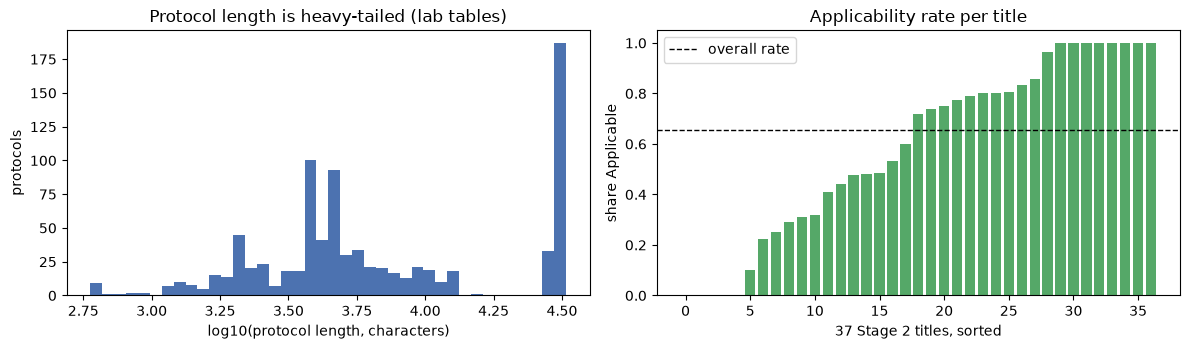

titles with rate 0 or 1: 13 of 37
in-sample AUC of the per-title rate alone: 0.874 (an upper bound, not a model)


In [7]:
# 3.3 How much of the Stage 2 label does the title alone decide?
by_title = train2.groupby("title_text")["label"].agg(rate="mean", n="size")
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(np.log10(proto.str.len()), bins=40, color="#4C72B0")
axes[0].set_xlabel("log10(protocol length, characters)")
axes[0].set_ylabel("protocols")
axes[0].set_title("Protocol length is heavy-tailed (lab tables)")
order = by_title.sort_values("rate")
axes[1].bar(range(len(order)), order["rate"], color="#55A868")
axes[1].axhline(train2["label"].mean(), color="k", lw=1, ls="--", label="overall rate")
axes[1].set_xlabel(f"{len(order)} Stage 2 titles, sorted")
axes[1].set_ylabel("share Applicable")
axes[1].set_title("Applicability rate per title")
axes[1].legend()
plt.tight_layout()
plt.show()

only_title_auc = roc_auc_score(train2["label"], train2["title_text"].map(by_title["rate"]))
print(f"titles with rate 0 or 1: {((by_title['rate'] == 0) | (by_title['rate'] == 1)).sum()} of {len(by_title)}")
print(f"in-sample AUC of the per-title rate alone: {only_title_auc:.3f} (an upper bound, not a model)")

**What the analysis changes.**
* **Stage 1 is condition detection.** Special titles name a restricted group:
  age, sex, pregnancy, severity, form or comorbidity. Condition-marker features
  and lemmatised words fit this better than topic words do.
* **Stage 2 protocols are long mostly because of lab tables.** Truncating them
  would cut arbitrary content, so the model reads *extracted* fields instead:
  demographics plus the complaints / anamnesis / objective status narrative
  (strategy E in the brief).
* **The title explains a large part of the Stage 2 label.** What is left is
  patient-specific: does the patient contradict the title's condition? The
  explicit contradiction-vs-unknown features in 6.2 target exactly that.

## 4. Russian medical text processing

Shared building blocks:
* **Lemmatisation.** `pymorphy3` maps each word to its dictionary form, so
  `тяжёлой`, `тяжелая` and `тяжелый` collapse into one feature, and the cache
  keeps it fast. Stage 1 keeps every word, because short titles need
  prepositions like `при` ("in patients with"). Stage 2 drops common function
  words from long protocols.
* **Negation.** Six patterns: `не …`, `нет …`, `отсутств…`, `отрицательн…`,
  `не выявлен…` and `не определя…`. Section 6.2 uses them to tell "the
  condition is mentioned and denied" apart from "the condition is present".
  **Known gap:** `отрицает`, `без` and a sentence-final `нет.` are not
  matched; the example below shows this.

In [8]:
# 4.1 Lemmatisation and negation
MORPH = pymorphy3.MorphAnalyzer()


@lru_cache(maxsize=300_000)
def lemma(word):
    return MORPH.parse(word)[0].normal_form


STAGE1_WORD = re.compile(r"[^\W\d_]+", re.UNICODE)
STAGE2_WORD = re.compile(r"[а-яёa-z]+", re.IGNORECASE)
RU_STOPWORDS = frozenset(
    "и в во не что он на я с со как а то все она так его но да ты к у же вы за бы по только ее "
    "мне было вот от меня еще нет о из ему теперь когда даже ну вдруг ли если уже или ни быть "
    "был него до вас нибудь опять уж вам для при".split()
)


def lemmatize_title(text):
    # Stage 1: every word, including short function words such as 'при'
    return " ".join(lemma(w) for w in STAGE1_WORD.findall(str(text).lower()))


def lemmatize_protocol(text):
    # Stage 2: stop words dropped, Latin tokens (drug names, units) kept
    tokens = STAGE2_WORD.findall(str(text).lower())
    return " ".join(lemma(t) for t in tokens if t not in RU_STOPWORDS)


NEGATION_PATTERN = re.compile(
    r"\bне\s+\w+|\bнет\s+\w+|отсутств\w*|отрицательн\w*|не\s+выявлен\w*|не\s+определя\w*",
    re.IGNORECASE,
)

print(lemmatize_title("Лечение пациентов с тяжёлой формой при беременности"))
print(lemmatize_protocol("Жалоб нет. Отёков не выявлено, беременность отрицает."))
print(NEGATION_PATTERN.findall("Жалоб нет. Отёков не выявлено, данных за кровотечение нет, тест отрицательный."))
print(NEGATION_PATTERN.findall("Травмы отрицает. Без особенностей. Жалоб нет."), "<- gap: none of these are matched")

лечение пациент с тяжёлый форма при беременность
жалоба отёк выявить беременность отрицать
['не выявлено', 'отрицательный']
[] <- gap: none of these are matched


## 5. Stage 1: General vs Special

A title is a hierarchical path:

```
Клинические рекомендации "<guideline>"
Возрастная категория: <age group>
# Лечение
## <section> ...
### <subsection>          <- the line that decides General vs Special
```

The model reads the path in four separate blocks, because each part carries a
different kind of signal:

| Block | Input | Why |
|---|---|---|
| `lex_subsection` | lemmatised last line, word 1–2-grams | the subsection names the population ("при беременности", "у детей") |
| `lex_context` | lemmatised guideline + age line + hierarchy | the parent section changes how the subsection reads |
| `char` | raw last line, char_wb 3–5-grams | absorbs morphology and rare medical terms that lemmatisation misses |
| `struct` | depth, length, punctuation, Latin/digits, **condition-marker counts** | brief §7: a Special title names age / gender / severity / form / comorbidity |

The classifier is logistic regression with balanced class weights. The
decision threshold is tuned for macro-F0.5, which needs probabilities.

In [9]:
# 5.1 Title parsing and patient-condition markers
@dataclass(frozen=True)
class TitleParts:
    guideline: str
    age_category: str
    hierarchy: tuple
    depth: int
    body: str

    @property
    def n_lines(self):
        return 3 + len(self.hierarchy)


def parse_title(text):
    # positional: line 0 = guideline, line 1 = age category, last = subsection
    lines = [ln.strip() for ln in str(text).split("\n")]
    while len(lines) < 2:
        lines.append("")
    sub = lines[-1]
    return TitleParts(lines[0], lines[1], tuple(lines[2:-1]),
                      len(sub) - len(sub.lstrip("#")), sub.lstrip("# ").strip())


# lemma sets for the patient-specificity dimensions named in the brief
CONDITION_GROUPS = {
    "age": {"ребёнок", "ребенок", "детский", "взрослый", "новорождённый", "новорожденный",
            "подросток", "год", "старше", "младше", "пожилой", "грудной", "младенец"},
    "gender": {"женщина", "мужчина", "беременный", "беременность", "кормящий",
               "лактация", "женский", "мужской", "роды", "послеродовой"},
    "severity": {"тяжёлый", "тяжелый", "лёгкий", "легкий", "среднетяжёлый", "среднетяжелый",
                 "степень", "стадия", "выраженный", "критический"},
    "form": {"форма", "тип", "вариант", "подтип", "течение", "фенотип"},
    "comorbidity": {"сопутствующий", "недостаточность", "осложнение", "осложнённый", "осложненный",
                    "сахарный", "диабет", "почечный", "печёночный", "печеночный", "сочетанный"},
    "refractory": {"рецидив", "резистентный", "рефрактерный", "повторный", "неэффективность"},
    "restriction": {"при", "случай", "пациент", "группа", "наличие"},
}
CONDITION_NAMES = tuple(sorted(CONDITION_GROUPS))

p = parse_title(train1["title_text"].iloc[1])
print(p, "| n_lines =", p.n_lines)

TitleParts(guideline='Клинические рекомендации "Рак ротоглотки"', age_category='Возрастная категория: Взрослые', hierarchy=('# Лечение',), depth=2, body='Иное лечение') | n_lines = 4


In [10]:
# 5.2 Feature blocks and model
LATIN = re.compile(r"[A-Za-z]{2,}")
DIGIT = re.compile(r"\d")
STRUCT_FEATURES = ("depth", "n_lines", "len_title", "len_subsection", "n_words_subsection",
                   "n_words_guideline", "has_latin", "has_digit", "n_parens", "n_commas",
                   "n_quotes", "n_cond_groups_sub", "n_cond_groups_ctx")


def title_context(p):
    return " ".join((p.guideline, p.age_category, " ".join(p.hierarchy)))


class TitleField(BaseEstimator, TransformerMixin):
    # select one part of the title: 'subsection' or 'context'; optionally lemmatise
    def __init__(self, which="subsection", lemma=True):
        self.which = which
        self.lemma = lemma

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        out = []
        for text in np.asarray(X, dtype=object):
            p = parse_title(text)
            picked = p.body if self.which == "subsection" else title_context(p)
            out.append(lemmatize_title(picked) if self.lemma else picked)
        return np.asarray(out, dtype=object)


class TitleStructFeatures(BaseEstimator, TransformerMixin):
    # layout statistics plus the number of condition groups hit in each part
    def fit(self, X, y=None):
        return self

    def get_feature_names_out(self, input_features=None):
        return np.asarray(STRUCT_FEATURES, dtype=object)

    def transform(self, X):
        return np.asarray([self._row(t) for t in np.asarray(X, dtype=object)], dtype=float)

    @staticmethod
    def _row(text):
        p = parse_title(text)
        sub = p.body
        sub_lemmas = set(lemmatize_title(sub).split())
        ctx_lemmas = set(lemmatize_title(title_context(p)).split())
        return [
            p.depth, p.n_lines, len(str(text)), len(sub), len(sub.split()),
            len(p.guideline.split()),
            int(bool(LATIN.search(sub))), int(bool(DIGIT.search(sub))),
            sub.count("("), sub.count(","), str(text).count('"'),
            sum(1 for g in CONDITION_NAMES if sub_lemmas & CONDITION_GROUPS[g]),
            sum(1 for g in CONDITION_NAMES if ctx_lemmas & CONDITION_GROUPS[g]),
        ]


def stage1_blocks():
    return [
        ("lex_subsection", Pipeline([("field", TitleField("subsection")),
                                     ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True))])),
        ("lex_context", Pipeline([("field", TitleField("context")),
                                  ("tfidf", TfidfVectorizer(ngram_range=(1, 1), min_df=2, sublinear_tf=True))])),
        ("char", Pipeline([("field", TitleField("subsection", lemma=False)),
                           ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=3,
                                                     sublinear_tf=True))])),
        ("struct", Pipeline([("extract", TitleStructFeatures()), ("scale", StandardScaler())])),
    ]


def build_stage1_model(C=1.0, blocks=None):
    kept = [(n, t) for n, t in stage1_blocks() if blocks is None or n in blocks]
    return Pipeline([
        ("features", FeatureUnion(kept)),
        ("clf", LogisticRegression(C=C, class_weight="balanced", max_iter=5000, random_state=SEED)),
    ])


THRESHOLD_GRID = np.round(np.arange(0.05, 0.96, 0.01), 2)


def tune_threshold(y_true, proba):
    # best macro-F0.5 threshold; ties broken towards 0.5
    scored = [(float(t), stage1_score(y_true, (proba >= t).astype(int))) for t in THRESHOLD_GRID]
    return max(scored, key=lambda kv: (kv[1], -abs(kv[0] - 0.5)))


X1 = train1["title_text"].to_numpy(dtype=object)
y1 = train1["label"].to_numpy()
X1_test = test1["title_text"].to_numpy(dtype=object)
CV1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def oof_proba(model, X, y, cv):
    return cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]

### 5.3 Feature-block ablation

Each block is added in turn, with 5-fold CV. The threshold is tuned on the same
out-of-fold predictions, so these scores are optimistic. They are for **ranking
the blocks only**; the honest estimate is the nested one in 5.4.

In [11]:
# 5.3 Block ablation (ranking only)
ABLATION_STEPS = {
    "lex_subsection": ("lex_subsection",),
    "+ lex_context": ("lex_subsection", "lex_context"),
    "+ char n-grams": ("lex_subsection", "lex_context", "char"),
    "+ struct / condition markers (final)": ("lex_subsection", "lex_context", "char", "struct"),
}
if RUN_STAGE1_ABLATION:
    rows = []
    for name, blocks in ABLATION_STEPS.items():
        p = oof_proba(build_stage1_model(C=1.0, blocks=blocks), X1, y1, CV1)
        t, s = tune_threshold(y1, p)
        rows.append({"blocks": name, "M1 @ 0.50": stage1_score(y1, (p >= 0.5).astype(int)),
                     "M1 tuned (optimistic)": s, "threshold": t})
    stage1_ablation = pd.DataFrame(rows).round(4)
    display(stage1_ablation)

,blocks,M1 @ 0.50,M1 tuned (optimistic),threshold
0,lex_subsection,0.6336,0.7347,0.65
1,+ lex_context,0.7021,0.7431,0.71
2,+ char n-grams,0.7493,0.7955,0.61
3,+ struct / condition markers (final),0.7842,0.8125,0.74


### 5.4 Nested cross-validation: choosing C and the threshold

**Outer loop.** 5 folds. Each outer fold is scored once, and never used for
tuning.

**Inner loop.** For each C and each outer training fold:
1. Run a 5-fold CV inside the outer training fold.
2. Pick the threshold that maximises macro-F0.5 on those inner predictions.
3. Refit on the whole outer training fold and score the held-out outer fold at
   that threshold.

**Selection.** C is chosen on the pooled nested M1. The final threshold is the
median of the five inner thresholds, so no test data and no outer-fold labels
are used to set it.

In [12]:
# 5.4 Nested CV over C
C_GRID = (1.0, 3.0, 10.0, 30.0)
RECORDED_SELECTION = {"C": 10.0, "threshold": 0.69, "pooled_m1": 0.8434134917185765}


def nested_cv(C, X, y, n_outer=5, n_inner=5):
    outer = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=SEED)
    thresholds, fold_scores = [], []
    y_pred = np.zeros(len(y), dtype=int)
    for fold, (tr, te) in enumerate(outer.split(X, y), start=1):
        inner = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=SEED + fold)
        t, _ = tune_threshold(y[tr], oof_proba(build_stage1_model(C), X[tr], y[tr], inner))
        model = build_stage1_model(C).fit(X[tr], y[tr])
        y_pred[te] = (model.predict_proba(X[te])[:, 1] >= t).astype(int)
        thresholds.append(t)
        fold_scores.append(stage1_score(y[te], y_pred[te]))
    return {"C": C, "pooled_m1": stage1_score(y, y_pred), "mean_fold_m1": float(np.mean(fold_scores)),
            "sd_fold_m1": float(np.std(fold_scores)), "thresholds": thresholds,
            "threshold_median": float(np.median(thresholds)), "y_pred": y_pred}


if RUN_STAGE1_SELECTION:
    nested = {C: nested_cv(C, X1, y1) for C in C_GRID}
    display(pd.DataFrame([{k: v for k, v in r.items() if k != "y_pred"} for r in nested.values()]).round(4))
    STAGE1_C = max(nested, key=lambda c: nested[c]["pooled_m1"])
    STAGE1_THRESHOLD = nested[STAGE1_C]["threshold_median"]
    stage1_nested_pred = nested[STAGE1_C]["y_pred"]
    assert (STAGE1_C, STAGE1_THRESHOLD) == (RECORDED_SELECTION["C"], RECORDED_SELECTION["threshold"]), \
        "selection differs from the recorded run"
    assert abs(nested[STAGE1_C]["pooled_m1"] - RECORDED_SELECTION["pooled_m1"]) < 1e-9
else:
    STAGE1_C, STAGE1_THRESHOLD = RECORDED_SELECTION["C"], RECORDED_SELECTION["threshold"]
    stage1_nested_pred = None
print(f"selected C = {STAGE1_C}, threshold = {STAGE1_THRESHOLD}")

,C,pooled_m1,mean_fold_m1,sd_fold_m1,thresholds,threshold_median
0,1.0,0.7819,0.7889,0.0799,"[0.73, 0.73, 0.59, 0.71, 0.72]",0.72
1,3.0,0.8212,0.8206,0.0596,"[0.71, 0.63, 0.77, 0.74, 0.72]",0.72
2,10.0,0.8434,0.8451,0.0373,"[0.73, 0.64, 0.69, 0.65, 0.79]",0.69
3,30.0,0.8396,0.8397,0.0526,"[0.78, 0.65, 0.77, 0.66, 0.81]",0.77


selected C = 10.0, threshold = 0.69


### 5.5 Why this architecture: the Stage 1 model history

All of these rows were measured in the project's experiment log (`h*/`
folders of the repository). The first three models were built while the
training titles were still the damaged `?` export. Their scores are low because
the words were missing, not because the models were weak.

| Model | Family | Validation M1 | Leaderboard M1 | Decision |
|---|---|---|---|---|
| char TF-IDF 2–5 + 6 meta features → LinearSVC (C1) | classical, damaged text | 0.465 (5-fold) | 0.629 | replaced |
| rubert-tiny2 fine-tune (T1) | transformer, damaged text | 0.458 (5-fold) | – | rejected: no gain, and the train/test alphabet gap can't be checked |
| masked "word-shape" invariant features (H14) | classical, corruption-invariant | 0.711 (nested) | – | replaced |
| invariant + partial Cyrillic decoding (H15) | classical, hybrid | 0.753 (nested) | – | replaced |
| **lemmatised word + char + condition markers (H17, this notebook)** | **classical, clean text** | **0.843 (nested)** | **0.922** | **final** |

**Why logistic regression over a transformer.** It has 1,767 short titles to
learn from. The deciding cue is lexical (a population word in the last line),
and word + char TF-IDF captures it directly. The model is also transparent: the
condition-marker block states the brief's definition of "Special" as features.

In [13]:
# 5.6 Final Stage 1 fit, and the Stage-2-title rule
stage1_model = build_stage1_model(STAGE1_C).fit(X1, y1)
stage1_proba = stage1_model.predict_proba(X1_test)[:, 1]
stage1_pred = (stage1_proba >= STAGE1_THRESHOLD).astype(int)

# Stage 2 is defined over Special subsections only, so a title that occurs in
# the Stage 2 data is Special by construction. Only titles are used, never labels.
# The rule is enabled only if it is 100% precise on the labelled Stage 1 data.
stage2_titles = set(train2["title_text"]) | set(test2["title_text"])
hit_train = train1["title_text"].isin(stage2_titles)
rule_precision = train1.loc[hit_train, "label"].mean()
RULE_ENABLED = bool(hit_train.any() and rule_precision == 1.0)
print(f"rule audit on train: {hit_train.sum()} matched, precision {rule_precision:.3f} -> enabled={RULE_ENABLED}")
if RULE_ENABLED:
    hit_test = test1["title_text"].isin(stage2_titles).to_numpy()
    print(f"rule on test: {hit_test.sum()} matched, {int(((stage1_pred == 0) & hit_test).sum())} predictions changed")
    stage1_pred[hit_test] = 1
print(f"Stage 1 test positive rate {stage1_pred.mean():.4f} (train prior {y1.mean():.4f})")

rule audit on train: 32 matched, precision 1.000 -> enabled=True
rule on test: 5 matched, 0 predictions changed
Stage 1 test positive rate 0.2195 (train prior 0.2168)


In [14]:
# 5.7 Error analysis on the nested out-of-fold predictions
def class_report(y_true, y_pred, names):
    p, r, f05, n = precision_recall_fscore_support(y_true, y_pred, beta=0.5, zero_division=0)
    _, _, f2, _ = precision_recall_fscore_support(y_true, y_pred, beta=2, zero_division=0)
    return pd.DataFrame({"precision": p, "recall": r, "F0.5": f05, "F2": f2, "support": n},
                        index=names).round(3)


if stage1_nested_pred is not None:
    print(class_report(y1, stage1_nested_pred, ["General", "Special"]))
    print("confusion (rows = true):\n", confusion_matrix(y1, stage1_nested_pred))
    err = train1.assign(pred=stage1_nested_pred, subsection=train1["title_text"].map(last_line))
    cond_hits = err["subsection"].map(
        lambda s: sum(1 for g in CONDITION_NAMES if set(lemmatize_title(s).split()) & CONDITION_GROUPS[g]))
    err["has_condition_marker"] = cond_hits > 0
    print("\nerror type vs presence of a condition marker in the subsection line:")
    print(pd.crosstab(np.select([(err.label == 1) & (err.pred == 0), (err.label == 0) & (err.pred == 1)],
                                ["FN (missed Special)", "FP (false Special)"], "correct"),
                      err["has_condition_marker"]))
    print("\nexamples of missed Special titles:")
    print(err[(err.label == 1) & (err.pred == 0)]["subsection"].head(8).to_string())
    print("\nexamples of false Special titles:")
    print(err[(err.label == 0) & (err.pred == 1)]["subsection"].head(8).to_string())

         precision  recall   F0.5     F2  support
General      0.933   0.960  0.939  0.955     1384
Special      0.840   0.752  0.821  0.768      383
confusion (rows = true):
 [[1329   55]
 [  95  288]]

error type vs presence of a condition marker in the subsection line:
has_condition_marker  False  True 
row_0                             
FN (missed Special)      57     38
FP (false Special)       22     33
correct                1363    254

examples of missed Special titles:
19                                     ### Особенности хирургического вмешательства при формировании тонкокишечного резервуара
66                                                                   ### Показания для повторного хирургического вмешательства
88       ### Пункционные интервенционные процедуры в области дугоотростчатых (фасеточных) суставов шейного отдела позвоночника
89                                                                                             ## Лептоменингеальное поражение
108     

**Reading the errors** (nested out-of-fold; precision on Special 0.84, recall 0.75).
* **Most missed Special titles (57 of 95) contain no condition marker.** They
  name the restricted group implicitly, through a situation or a disease
  variant: "Показания для повторного хирургического вмешательства",
  "Лептоменингеальное поражение", "Терапия пациентов с хронической ИТП".
* **Most false Special titles (33 of 55) do contain a marker**, used where the
  annotators saw a general section: "Лечение ортопедических осложнений
  гемофилии", "Терапия рецидивов и резистентных форм …", "Лечение локальных
  стадий заболевания (I-II)".
* **So a marker word points towards Special but doesn't settle it.** That is
  why the markers are one feature block among four, not a rule. Some of these
  labels are debatable even for a clinician.

## 6. Stage 2: applicability as condition matching

The brief's key rule: **unknown ≠ contradiction**. A subsection is "Not
applicable" only when the protocol *clearly contradicts* the title's condition.
Missing evidence means "Applicable". The pipeline turns that rule into
features:

```
title  ──► required condition (age bound, sex, severity, disease terms)
protocol ──► patient facts (structured Пол/Возраст, narrative, negations)
                     │
                     ▼
     for each condition: satisfied / CONTRADICTED / UNKNOWN
                     │
                     ▼
lemmatised title + narrative TF-IDF  +  demographics  +  11 state features
                     │
                     ▼
     logistic regression (balanced), threshold 0.5
```

### 6.1 Long protocols: field extraction instead of truncation

The median protocol row has about 4,800 characters, and 187 of 863 rows are
cut at 32,765. 78% of all protocol characters are lab-table lines
(section 3.2). Instead of truncating,
the pipeline extracts the fields that carry patient facts:

* **Structured header.** `Пол` and `Возраст`, with a regex fallback for age in
  free text.
* **Narrative.** The `Жалобы` / `Анамнез` / `Объективный статус` sections, a
  median of about 19% of the text.
* **Counts.** The number of negations, and the protocol length.

**Sex is read only from the structured `Пол:` field.** Guessing it from words
like "пациентка" produced false contradictions and was dropped.

In [15]:
# 6.1 Protocol field extraction
NARRATIVE_FIELDS = ("Жалобы", "Анамнез", "Объективный статус")


def extract_field(text, field):
    m = re.search(rf"{re.escape(field)}\s*:\s*(.+)", text)
    return m.group(1).strip() if m else None


def extract_age(text):
    structured = extract_field(text, "Возраст")
    if structured is not None:
        m = re.search(r"\d{1,3}", structured)
        if m:
            return float(m.group())
    m = re.search(r"(\d{1,3})\s*[- ]?\s*(лет|года|год)\b", text)
    return float(m.group(1)) if m else np.nan


def extract_gender(text):
    structured = extract_field(text, "Пол")  # structured field only, never guessed
    if structured:
        s = structured.lower()
        if s.startswith("ж"):
            return "F"
        if s.startswith("м"):
            return "M"
    return None


def extract_narrative(text):
    chunks = []
    for field in NARRATIVE_FIELDS:
        m = re.search(rf"{re.escape(field)}\s*:\s*(.+?)(?=\n[А-ЯЁ][^\n:]{{0,40}}:|\Z)", text, re.DOTALL)
        if m:
            chunks.append(m.group(1).strip())
    return " ".join(chunks) if chunks else text  # no sections found: keep the whole text


def extract_protocol_fields(protocols):
    s = pd.Series(protocols).astype(str).reset_index(drop=True)
    return pd.DataFrame({
        "gender_raw": s.map(extract_gender),
        "age": s.map(extract_age),
        "has_structured_header": s.str.contains(r"Пол\s*:", regex=True).astype(int),
        "negation_count": s.map(lambda t: len(NEGATION_PATTERN.findall(t))),
        "protocol_len": s.str.len(),
        "narrative_text": s.map(extract_narrative),
    })


example = extract_protocol_fields(train2["protocol_text"].iloc[:1]).iloc[0]
print({k: (v[:160] + "...") if isinstance(v, str) and len(v) > 160 else v for k, v in example.items()})

{'gender_raw': 'F', 'age': np.float64(34.0), 'has_structured_header': np.int64(1), 'negation_count': np.int64(8), 'protocol_len': np.int64(11283), 'narrative_text': 'на периодические боли в поясничной области 18.01 ДЛТ отмечала отхождение камней Состояние удовлетворительное. Живот мягкий, безболезненный. Симптом поколачивани...'}


### 6.2 Condition matching: satisfied, contradicted or unknown

For each condition type, the title defines a rule, and the protocol either
satisfies it, contradicts it, or leaves it **unknown**. Unknown gets its own
feature, so the model can learn that missing evidence is not a contradiction.

| Condition | From the title | From the protocol | Features |
|---|---|---|---|
| age | upper bound `до N лет` | structured / free-text age | `age_contradiction` (age above the bound) |
| sex | female topics (endometriosis, pregnancy, breast, uterus, ovary, …) or male topics (prostate, …) | structured `Пол` | `gender_condition_present`, `gender_unknown` (sex missing, or a pregnancy title, where sex alone can't decide) |
| severity | mild / moderate / severe level | severity words in the narrative | `severity_match`, `severity_contradiction`, `severity_unknown` |
| disease terms | informative title lemmas | narrative lemmas + **negation window** | `condition_overlap`, `condition_contradiction` (a shared term within 40 characters of a negation), `condition_unknown` (term never mentioned) |
| aggregate | | | `contradiction_count`, `contradiction_density` |

**Determinism.** An earlier version checked the first five shared terms of a
Python `set`, whose order changes between processes. The terms are now sorted
first.

In [16]:
# 6.2 Contradiction / unknown features
SEVERITY_TERMS = {
    "легкий": 1, "лёгкий": 1, "легкая": 1, "лёгкая": 1, "легкое": 1,
    "среднетяжелый": 2, "среднетяжёлый": 2, "умеренный": 2, "умеренная": 2, "средний": 2, "средняя": 2,
    "тяжелый": 3, "тяжёлый": 3, "тяжелая": 3, "тяжёлая": 3, "тяжелое": 3, "выраженный": 3, "выраженная": 3,
}
GENERIC_TITLE_WORDS = {
    "клинический", "рекомендация", "лечение", "особенность", "пациент", "терапия", "взрослый",
    "категория", "возрастной", "консервативный", "хирургический", "медикаментозный", "группа",
    "локализация", "форма", "период", "снизить", "кроме", "прочий", "другой", "определённый",
}
FEMALE_TOPICS = ("эндометриоз", "беремен", "контрацептив", " мгт", "ддмж", "молочн", "маточ", "яичник", "гинеколог")
MALE_TOPICS = ("простат", "мужского пола")
PREGNANCY_MARKERS = ("беремен", "грудно", "лактац", "кормлен")
CONTRADICTION_COLS = [
    "age_contradiction", "gender_condition_present", "gender_unknown", "severity_match",
    "severity_contradiction", "severity_unknown", "condition_overlap", "condition_contradiction",
    "condition_unknown", "contradiction_count", "contradiction_density",
]


def title_age_bound(title):
    m = re.search(r"до\s*(\d{1,3})\s*лет", str(title), re.IGNORECASE)
    return float(m.group(1)) if m else np.nan


def title_required_gender(title):
    low = str(title).lower()
    if any(k in low for k in FEMALE_TOPICS):
        return "F"
    if any(k in low for k in MALE_TOPICS):
        return "M"
    return None


def severity_level(lemmas):
    levels = {SEVERITY_TERMS[t] for t in set(str(lemmas).split()) if t in SEVERITY_TERMS}
    return max(levels) if levels else np.nan


def title_condition_terms(title_lemma):
    return {t for t in str(title_lemma).split() if len(t) > 3 and t not in GENERIC_TITLE_WORDS}


def negated_near(text, token, window=40):
    for m in NEGATION_PATTERN.finditer(text):
        if token in text[max(0, m.start() - window): m.end() + window]:
            return True
    return False


def contradiction_features(df):
    # df: title_text, title_lemma, narrative_text, narrative_lemma, age, gender_raw
    out = pd.DataFrame(index=df.index)
    bound = df["title_text"].map(title_age_bound)
    out["age_contradiction"] = (bound.notna() & df["age"].notna() & (df["age"] > bound)).astype(int)

    required = df["title_text"].map(title_required_gender)
    pregnancy = df["title_text"].map(lambda t: any(k in str(t).lower() for k in PREGNANCY_MARKERS))
    out["gender_condition_present"] = required.notna().astype(int)
    out["gender_unknown"] = (required.notna() & (df["gender_raw"].isna() | pregnancy)).astype(int)

    t_sev = df["title_lemma"].map(severity_level)
    n_sev = df["narrative_lemma"].map(severity_level)
    out["severity_match"] = (t_sev.notna() & n_sev.notna() & (t_sev == n_sev)).astype(int)
    out["severity_contradiction"] = (t_sev.notna() & n_sev.notna() & (t_sev != n_sev)).astype(int)
    out["severity_unknown"] = (t_sev.notna() & n_sev.isna()).astype(int)

    terms = df["title_lemma"].map(title_condition_terms)
    overlap, contra = [], []
    for term_set, narr_lemma, narr_text in zip(terms, df["narrative_lemma"], df["narrative_text"]):
        shared = term_set & set(str(narr_lemma).split())
        overlap.append(int(bool(shared)))
        low = str(narr_text).lower()
        contra.append(int(bool(shared) and any(negated_near(low, tok) for tok in sorted(shared)[:5])))
    out["condition_overlap"] = overlap
    out["condition_contradiction"] = contra
    out["condition_unknown"] = ((out["condition_overlap"] == 0) & (terms.map(len) > 0)).astype(int)

    gender_contradiction = (required.notna() & df["gender_raw"].notna()
                            & (df["gender_raw"] != required)).astype(int)
    out["contradiction_count"] = (out["age_contradiction"] + gender_contradiction
                                  + out["severity_contradiction"] + out["condition_contradiction"])
    n_rules = (bound.notna().astype(int) + required.notna().astype(int)
               + t_sev.notna().astype(int) + (terms.map(len) > 0).astype(int))
    out["contradiction_density"] = (out["contradiction_count"] / n_rules.replace(0, np.nan)).fillna(0.0)
    return out[CONTRADICTION_COLS]


def build_stage2_frame(df):
    frame = df.reset_index(drop=True).copy()
    frame["title_lemma"] = frame["title_text"].map(lemmatize_protocol)
    frame = pd.concat([frame, extract_protocol_fields(frame["protocol_text"])], axis=1)
    frame["narrative_lemma"] = frame["narrative_text"].map(lemmatize_protocol)
    frame["gender"] = frame["gender_raw"].fillna("unknown")
    return pd.concat([frame, contradiction_features(frame)], axis=1)


t0 = time.time()
X2 = build_stage2_frame(train2)
X2_test = build_stage2_frame(test2)
y2 = X2["label"].to_numpy()
print(f"Stage 2 frames built in {time.time() - t0:.0f}s: train {X2.shape}, test {X2_test.shape}")

Stage 2 frames built in 3s: train (690, 24), test (173, 23)


In [17]:
# 6.2b Does the unknown / contradicted distinction show up in the labels?
states = {
    "age contradicted": X2["age_contradiction"] == 1,
    "sex-specific title, sex unknown or pregnancy": X2["gender_unknown"] == 1,
    "sex-specific title, sex known": (X2["gender_condition_present"] == 1) & (X2["gender_unknown"] == 0),
    "severity matches": X2["severity_match"] == 1,
    "severity contradicted": X2["severity_contradiction"] == 1,
    "severity unknown": X2["severity_unknown"] == 1,
    "disease term present, not negated": (X2["condition_overlap"] == 1) & (X2["condition_contradiction"] == 0),
    "disease term present and negated": X2["condition_contradiction"] == 1,
    "disease term never mentioned (unknown)": X2["condition_unknown"] == 1,
    "all rows": pd.Series(True, index=X2.index),
}
state_table = pd.DataFrame({name: {"rows": int(m.sum()), "share Applicable": y2[m.to_numpy()].mean()}
                            for name, m in states.items()}).T
state_table["rows"] = state_table["rows"].astype(int)
display(state_table.round(3))

,rows,share Applicable
age contradicted,17,0.000
"sex-specific title, sex unknown or pregnancy",18,0.333
"sex-specific title, sex known",51,0.039
severity matches,8,0.875
severity contradicted,19,0.947
severity unknown,58,0.983
"disease term present, not negated",418,0.706
disease term present and negated,58,0.707
disease term never mentioned (unknown),214,0.547
all rows,690,0.657


**Reading the table** (these are label rates in the training data, not model
output).
* **Age contradiction is decisive:** 17 rows, none of them Applicable.
* **Sex shows the unknown-vs-contradiction split most clearly.** When a
  sex-specific title meets a patient whose sex is known, only 4% of rows are
  Applicable. When sex is unknown (or the title is about pregnancy, which sex
  alone can't decide), 33% are. Treating "unknown" like "contradicted" would
  throw those rows away.
* **Some detectors carry little signal on their own.**
  * The lexical severity match barely separates the classes: all three
    severity states are mostly Applicable.
  * A negation near a disease term leaves the rate unchanged (0.707 vs 0.706),
    in line with experiment H19, where finer negation scoping lowered M2.
* **A title's disease terms never appearing in the narrative lowers the rate
  (0.55 vs 0.66)**, but not below one half. It is soft evidence, not a
  contradiction.
* **That is why these states go into the model as features, not overrides.**
  Only the precise ones (age) act as near-hard evidence, and the model learns
  the weights.

In [18]:
# 6.3 The Stage 2 model (config G)
STAGE2_NUMERIC = ["age", "has_structured_header", "negation_count", "protocol_len"]
STAGE2_THRESHOLD = 0.5


def numeric_block():
    return Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])


def build_stage2_model(title=True, narrative=True, demographics=True, contradiction=True):
    blocks = []
    if title:
        blocks.append(("title_tfidf", TfidfVectorizer(min_df=2), "title_lemma"))
    if narrative:
        blocks.append(("narrative_tfidf", TfidfVectorizer(min_df=2, max_features=20_000), "narrative_lemma"))
    if demographics:
        blocks.append(("numeric", numeric_block(), STAGE2_NUMERIC))
        blocks.append(("gender", OneHotEncoder(handle_unknown="ignore"), ["gender"]))
    if contradiction:
        blocks.append(("contradiction", numeric_block(), CONTRADICTION_COLS))
    return Pipeline([
        ("features", ColumnTransformer(blocks)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ])


STAGE2_VARIANTS = {
    "title TF-IDF only": dict(narrative=False, demographics=False, contradiction=False),
    "narrative TF-IDF only": dict(title=False, demographics=False, contradiction=False),
    "title + narrative": dict(demographics=False, contradiction=False),
    "+ demographics & counts (C2)": dict(contradiction=False),
    "+ contradiction/unknown features (G, final)": dict(),
}

### 6.4 Validation

**Primary split.** The fixed 5-fold stratified split (seed 42) that every Stage
2 experiment in the project used.

**Stability check.** A 5 × 5 repeated split (seeds 0–4), because a single
5-fold split of 690 rows moves by about ±0.02 M2 from the split alone. The
spread across repeats shows how much of any difference is noise.

**Fold safety.**
* Every learned transform (TF-IDF vocabulary, imputer, scaler, one-hot
  categories) is fitted inside the pipeline, per fold.
* The contradiction features are row-local: one (title, protocol) pair in, one
  value out. No labels or corpus statistics go into them.

In [19]:
# 6.4 Component ablation: fixed split and 5x5 repeated CV
CV2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)


def evaluate_stage2(model, splits_list):
    per_repeat, probas = [], []
    for splits in splits_list:
        proba = cross_val_predict(model, X2, y2, cv=splits, method="predict_proba", n_jobs=-1)[:, 1]
        per_repeat.append(stage2_score(y2, (proba >= STAGE2_THRESHOLD).astype(int)))
        probas.append(proba)
    return per_repeat, probas


repeated_splits = [list(StratifiedKFold(5, shuffle=True, random_state=s).split(X2, y2)) for s in range(5)]
rows, stage2_oof = [], None
for name, kw in STAGE2_VARIANTS.items():
    (m2_fixed,), (proba,) = evaluate_stage2(build_stage2_model(**kw), [list(CV2.split(X2, y2))])
    row = {"model": name, "M2 fixed split": m2_fixed, "AUC": roc_auc_score(y2, proba)}
    if RUN_STAGE2_REPEATED_CV:
        rep, _ = evaluate_stage2(build_stage2_model(**kw), repeated_splits)
        row.update({"M2 5x5 mean": np.mean(rep), "M2 5x5 sd": np.std(rep, ddof=1)})
    rows.append(row)
    stage2_oof = proba  # the last variant is the final model
stage2_ablation = pd.DataFrame(rows).round(4)
display(stage2_ablation)

STAGE2_REFERENCE_M2 = 0.7023868247508647
assert abs(stage2_ablation.iloc[-1]["M2 fixed split"] - round(STAGE2_REFERENCE_M2, 4)) < 1e-4
print(f"final model reproduces the recorded fixed-split M2 {STAGE2_REFERENCE_M2:.4f}")

,model,M2 fixed split,AUC,M2 5x5 mean,M2 5x5 sd
0,title TF-IDF only,0.5959,0.8416,0.5853,0.0095
1,narrative TF-IDF only,0.4357,0.7532,0.4359,0.0209
2,title + narrative,0.6819,0.8956,0.7056,0.0106
3,+ demographics & counts (C2),0.6794,0.8924,0.6924,0.0066
4,"+ contradiction/unknown features (G, final)",0.7024,0.8884,0.6993,0.0070


final model reproduces the recorded fixed-split M2 0.7024


**Reading the ablation.**
* **The title alone is a strong ranker** (AUC 0.84), as section 3.3 predicted.
  The narrative alone is weak.
* **Title + narrative is the big step:** +0.09 to +0.12 M2.
* **The last two blocks don't add measurable M2 on average.**
  * On the fixed split, the contradiction block adds +0.023 (0.679 → 0.702);
    that result is why experiment H8 promoted it.
  * On the 5 × 5 repeated split, title + narrative (0.706), C2 (0.692) and G
    (0.699) lie within about one standard deviation of each other.
  * The fixed-split gain was mostly split luck, which is exactly the
    blindness to small effects that motivated the repeated-CV harness.
* **Why G is still the final model:**
  * it is the model the leaderboard verified (55.168);
  * its explicit condition states are what make each prediction explainable
    (6.2);
  * no alternative beat it on repeated CV either.
  Choosing a different variant now, on a difference of 0.006, would be
  selection on noise.

In [20]:
# 6.5 Threshold: why 0.5
sweep = pd.DataFrame([
    {"threshold": t, "M2": stage2_score(y2, (stage2_oof >= t).astype(int)),
     "recall Applicable": ((stage2_oof >= t) & (y2 == 1)).sum() / (y2 == 1).sum(),
     "FN": int(((stage2_oof < t) & (y2 == 1)).sum()), "FP": int(((stage2_oof >= t) & (y2 == 0)).sum()),
     "positive rate": (stage2_oof >= t).mean()}
    for t in np.round(np.arange(0.30, 0.66, 0.05), 2)
]).round(4)
display(sweep)

,threshold,M2,recall Applicable,FN,FP,positive rate
0,0.30,0.5393,0.9338,30,108,0.7696
1,0.35,0.6011,0.9051,43,88,0.7217
2,0.40,0.6219,0.8764,56,76,0.6855
3,0.45,0.6442,0.8543,66,65,0.6551
4,0.50,0.7024,0.8212,81,42,0.6000
5,0.55,0.6838,0.7837,98,35,0.5652
6,0.60,0.6402,0.7373,119,31,0.5290
7,0.65,0.5892,0.6711,149,22,0.4725


**Threshold 0.5 is kept.**
* **Class weights already set the operating point.** The model is trained
  with balanced class weights, so 0.5 is its natural cut.
* **The best in-sample threshold is 0.5 or close to it.** Neighbouring
  thresholds lose M2.
* **Tuning didn't help out of sample.** A threshold tuned inside a nested CV
  (experiment H22) scored *lower*, 0.688 vs 0.702.
* **A higher threshold (0.54, experiment H7) was rejected.** It raised M2 by
  giving up recall on "Applicable", which is the error the brief calls most
  costly.

### 6.6 Why this architecture: what was tried and rejected

All numbers come from the project's experiment log; each experiment was
compared with the same split or with paired repeated CV. "Δ" is measured
against config G unless stated otherwise.

| Experiment | Family | Result | Decision |
|---|---|---|---|
| plain word TF-IDF → LR | classical | M2 0.391 | baseline |
| field extraction + lemmas + numeric → LR (C2) | classical, structured | M2 0.679 | superseded by G |
| C2 with LinearSVC | classical | M2 0.660 | rejected |
| rubert-tiny2 on title + narrative (T2) | transformer | M2 0.496 | rejected |
| … head + tail of the protocol (T3) | transformer, long-text | M2 0.477 | rejected |
| … structured field template (T4) | transformer, extraction | M2 0.540 (72% of inputs truncated) | rejected |
| transformer embedding + C2 features (H1) | hybrid | M2 0.454 | rejected |
| **C2 + 11 contradiction / unknown features (G)** | **classical + condition matching** | **M2 0.702** | **final** |
| scoped negation, condition presence (H19) | rules | Δ −0.036 | rejected |
| protocol / title recurrence, fold-safe (H21) | lookups | Δ −0.006 | rejected |
| per-title calibration / less title weight (H23) | post-hoc | best Δ +0.001, mean over seeds −0.008 | rejected (seed artifact) |
| + ICD-10 code + diagnosis text (H24 C0) | classical, more inputs | 5×5 Δ +0.022, but p = 0.136 on fresh seeds; **leaderboard 54.80 < 55.17** | rejected |
| CatBoost on TF-IDF-SVD + categorical features (H24) | gradient boosting | 5×5 Δ −0.017 | rejected |
| per-title feature copies (H24) | interaction model | 5×5 Δ +0.013, not significant | rejected |
| zero-shot Qwen2.5-7B-Instruct probability as a feature (H24 D) | LLM | Δ vs C0 −0.011 / −0.008 | rejected |

**Why a linear model with explicit condition features wins here:**
1. **690 rows is too few** to learn "does the patient contradict the title?"
   from raw text. Every transformer variant scored well below the classical
   pipeline, and more careful input design didn't close the gap.
2. **The contradiction features encode that reasoning directly**, and they
   keep *unknown* separate from *contradicted*, as the brief requires. Their
   measurable M2 gain is small (6.4); their value is that decisive rules, such
   as the age bound, are explicit and inspectable.
3. **Each prediction can be explained** from its TF-IDF weights and the named
   condition states.
4. **It is stable.** Additions that looked better on one split (ICD code,
   per-title calibration) did not hold up on fresh seeds or on the leaderboard.

In [21]:
# 6.7 Error analysis (out of fold, fixed split)
pred_oof = (stage2_oof >= STAGE2_THRESHOLD).astype(int)
print(class_report(y2, pred_oof, ["Not applicable", "Applicable"]))
print("confusion (rows = true):\n", confusion_matrix(y2, pred_oof))

err2 = X2.assign(proba=stage2_oof, pred=pred_oof, subsection=X2["title_text"].map(last_line))
per_title = err2.groupby("subsection").apply(
    lambda g: pd.Series({
        "rows": len(g), "share Applicable": g["label"].mean(), "FN": int(((g.label == 1) & (g.pred == 0)).sum()),
        "FP": int(((g.label == 0) & (g.pred == 1)).sum()),
        "within-title AUC": roc_auc_score(g["label"], g["proba"]) if g["label"].nunique() == 2 else np.nan,
    }), include_groups=False,
).sort_values("FN", ascending=False)
print("\ntitles with the most missed 'Applicable' rows:")
display(per_title.head(8).round(3))
fn_top = per_title.head(7)
print(f"the top 7 titles hold {int(fn_top['FN'].sum())} of {int(per_title['FN'].sum())} false negatives; "
      f"their mean within-title AUC is {fn_top['within-title AUC'].mean():.2f}")

                precision  recall   F0.5     F2  support
Not applicable      0.707   0.823  0.727  0.797      237
Applicable          0.899   0.821  0.882  0.836      453
confusion (rows = true):
 [[195  42]
 [ 81 372]]

titles with the most missed 'Applicable' rows:


,rows,share Applicable,FN,FP,within-title AUC
subsection,,,,,
"## Особенности лечения ГБН, сочетающейся с лекарственно-индуцированной головной болью (ЛИГБ)",21.0,0.476,10.0,1.0,0.218
### Хирургическое лечение БК в форме терминального илеита или илеоколита,19.0,0.737,9.0,0.0,0.714
### Лечение БК с перианальными проявлениями (перианальная БК),17.0,0.412,7.0,1.0,0.314
### Медикаментозная терапия при эрозивном гастрите и дуодените,20.0,0.800,7.0,3.0,0.344
### Хирургическое лечение БК с поражением верхних отделов ЖКТ,22.0,0.318,7.0,0.0,0.743
### Рекомендации по начальному лечению пациентов с хронической сердечной недостаточностью и фибрилляцией предсердий с высокой частотой желудочковых сокращений в острой или хронической ситуации,24.0,0.292,5.0,2.0,0.773
## Особенности лечения БА у беременных и в период грудного вскармливания,16.0,0.312,5.0,2.0,0.491
### БК тонкой кишки (кроме терминального илеита),18.0,0.222,4.0,0.0,0.804


the top 7 titles hold 50 of 81 false negatives; their mean within-title AUC is 0.51


**What the remaining errors are.**
* **The false negatives are concentrated:** 7 titles hold 50 of the 81. Many
  of those titles have a low Applicable rate, so the model ranks their rows
  low *as a group*.
* **Inside such titles the ranking is uneven.** Within-title AUC is 0.2–0.3
  for some (worse than chance) and 0.7–0.8 for others.
* **The positives there depend on one free-text fact**, such as pregnancy,
  upper-GI involvement or a cancer history, often phrased in ways the lemma
  vocabulary never saw under that title. This is the model's main limitation.
* **Rejected fixes.** Per-title calibration (H23) and extra diagnosis inputs
  (H24) were tried against it; see 6.6.
* **Plausible next step.** A condition-extraction model trained on
  (condition, evidence) pairs, which needs more labelled data than the 690 rows
  available.

In [22]:
# 6.8 Final Stage 2 fit and test predictions
stage2_model = build_stage2_model().fit(X2, y2)
assert (X2_test["id"].to_numpy() == test2["id"].to_numpy()).all(), "test order changed"
stage2_proba = stage2_model.predict_proba(X2_test)[:, 1]
stage2_pred = (stage2_proba >= STAGE2_THRESHOLD).astype(int)
print(f"Stage 2 test positive rate {stage2_pred.mean():.4f} (train prior {y2.mean():.4f})")

Stage 2 test positive rate 0.5434 (train prior 0.6565)


## 7. Submission and reproducibility check

Before writing, the notebook checks:
* **Columns and length:** `stage, id, label` with 442 + 173 rows.
* **Row order:** the same as the test files.
* **Labels:** binary only.
* **Fingerprint:** the label sequence of each stage must match the SHA-256
  of the submission that scored 55.168.
* **Whole file:** the written `submission.csv` must be byte-identical to the
  file uploaded to the platform, so the leaderboard score applies to it.

In [23]:
# 7.1 Assemble, validate, write
EXPECTED_FINGERPRINT = {
    1: "2b69d508db83bb0425b6302e7c11c62ea0e2780c92f78428b0a6406d65548e5e",
    2: "6dbaea4e69e221956017c09ad2e3dc14791074441505deeb57d88d401a72890b",
}

submission = pd.concat([
    pd.DataFrame({"stage": 1, "id": test1["id"].to_numpy(), "label": stage1_pred}),
    pd.DataFrame({"stage": 2, "id": test2["id"].to_numpy(), "label": stage2_pred}),
], ignore_index=True)

assert list(submission.columns) == ["stage", "id", "label"]
assert len(submission) == len(test1) + len(test2) == 615
assert submission["label"].isin([0, 1]).all()
for stage, test in ((1, test1), (2, test2)):
    part = submission[submission["stage"] == stage]
    assert (part["id"].to_numpy() == test["id"].to_numpy()).all(), f"stage {stage} row order"
    labels = "".join(map(str, part["label"]))
    got = hashlib.sha256(labels.encode()).hexdigest()
    status = "MATCH" if got == EXPECTED_FINGERPRINT[stage] else "DIFFERENT"
    print(f"stage {stage}: {len(part)} rows, positive rate {part['label'].mean():.4f}, fingerprint {status}")
    assert status == "MATCH", f"stage {stage} predictions differ from the submitted file"

SUBMISSION_PATH = OUTPUT_DIR / "submission.csv"
# The submitted file was written on Windows with CRLF line endings; fixing the
# terminator makes the bytes identical on Linux (Colab) too.
submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8", lineterminator="\r\n")

# SHA-256 of the exact file uploaded to the platform (leaderboard 55.168;
# archived in the repository as h17/submission_stage1_clean.csv)
SUBMITTED_FILE_SHA256 = "5cd35e4dcba7f5a8bcef21e21b9689440a413e2712c6a65258136a957e8945a6"
written_sha = sha256_of(SUBMISSION_PATH)
print("wrote", SUBMISSION_PATH, "sha256", written_sha)
print("byte-identical to the submitted file:", written_sha == SUBMITTED_FILE_SHA256)
assert written_sha == SUBMITTED_FILE_SHA256, "submission.csv differs from the submitted file"

stage 1: 442 rows, positive rate 0.2195, fingerprint MATCH
stage 2: 173 rows, positive rate 0.5434, fingerprint MATCH
wrote outputs\submission.csv sha256 5cd35e4dcba7f5a8bcef21e21b9689440a413e2712c6a65258136a957e8945a6
byte-identical to the submitted file: True


In [24]:
# 7.2 Run manifest
manifest = {
    "environment": ENV,
    "stage1": {"C": STAGE1_C, "threshold": STAGE1_THRESHOLD, "rule_enabled": RULE_ENABLED,
               "test_positive_rate": float(stage1_pred.mean())},
    "stage2": {"threshold": STAGE2_THRESHOLD, "features": CONTRADICTION_COLS + STAGE2_NUMERIC,
               "test_positive_rate": float(stage2_pred.mean())},
    "submission_sha256": hashlib.sha256(SUBMISSION_PATH.read_bytes()).hexdigest(),
    "fingerprints": EXPECTED_FINGERPRINT,
    "runtime_seconds": round(time.time() - T_START),
}
(OUTPUT_DIR / "run_manifest.json").write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(manifest, indent=1, ensure_ascii=False))

{
 "environment": {
  "python": "3.14.6",
  "numpy": "2.4.6",
  "pandas": "3.0.3",
  "scipy": "1.18.0",
  "scikit-learn": "1.9.0",
  "pymorphy3": "2.0.6",
  "pymorphy3-dicts-ru": "2.4.417150.4580142",
  "seed": 42
 },
 "stage1": {
  "C": 10.0,
  "threshold": 0.69,
  "rule_enabled": true,
  "test_positive_rate": 0.21945701357466063
 },
 "stage2": {
  "threshold": 0.5,
  "features": [
   "age_contradiction",
   "gender_condition_present",
   "gender_unknown",
   "severity_match",
   "severity_contradiction",
   "severity_unknown",
   "condition_overlap",
   "condition_contradiction",
   "condition_unknown",
   "contradiction_count",
   "contradiction_density",
   "age",
   "has_structured_header",
   "negation_count",
   "protocol_len"
  ],
  "test_positive_rate": 0.5433526011560693
 },
 "submission_sha256": "5cd35e4dcba7f5a8bcef21e21b9689440a413e2712c6a65258136a957e8945a6",
 "fingerprints": {
  "1": "2b69d508db83bb0425b6302e7c11c62ea0e2780c92f78428b0a6406d65548e5e",
  "2": "6dbaea4e69e2

## 8. Results, architecture choice, limitations

### Scores

| | Validation (train only) | Leaderboard |
|---|---|---|
| M1 (Stage 1) | 0.843 nested 5-fold | 0.922 |
| M2 (Stage 2) | 0.702 fixed 5-fold (0.699 ± 0.007 over 5 × 5) | 0.731 |
| Points (of 70) | 52.1 | **55.168** |

Validation came in below the leaderboard on both stages. One reason is that
the final models are trained on all of the training data, while each
validation fold sees only 80%. Validation was used **only to compare models**;
submissions were never tuned on leaderboard feedback.

| Submission | Leaderboard | Note |
|---|---|---|
| C1 (char TF-IDF, damaged titles) + G | 49.02 | first frozen pipeline |
| **H17 clean-text Stage 1 + G** | **55.17** | **final** |
| H17 + C0 (G + ICD code + diagnosis text) | 54.80 | rejected: a CV gain that did not transfer |

### Why this architecture

* **Stage 1 treats "Special" as "names a restricted population".**
  Lemmatised word n-grams read the subsection and its context separately, char
  n-grams handle morphology, and explicit condition-marker counts encode the
  brief's definition. A title that also occurs in the Stage 2 data is marked
  Special; this rule is 100% precise on train.
* **Stage 2 treats applicability as condition matching.** The title gives a
  condition, the protocol gives facts, and the features separate
  *satisfied*, *contradicted* and *unknown*. A regularised linear model on top
  was the most accurate and most stable option among classical models,
  transformers, gradient boosting and a zero-shot LLM.

### Russian medical text handling

* **Morphology.** pymorphy3 lemmatisation plus char n-grams.
* **Terminology.** Condition-marker lemma sets for age, sex/pregnancy,
  severity, form, comorbidity and refractory disease; severity-level mapping;
  sex-specific topic lexicon.
* **Negation.** Six patterns (`не`, `нет`, `отсутств…`, `отрицательн…`,
  `не выявлен…`, `не определя…`), used as a count and inside a 40-character
  scope around each disease term.
* **Long protocols.** Field extraction instead of truncation: 78% of protocol
  characters are lab-table lines.
* **Unknown ≠ contradiction.** Separate feature states.

### Limitations

* **Within-title ranking is the ceiling.** In a few low-prevalence titles,
  Stage 2 ranks rows close to chance, and most false negatives are there.
* **The negation scope is a character window**, not a syntactic parse, so
  negations of neighbouring terms can leak into it. Section 6.2 shows the
  resulting flag carries almost no label signal, and the patterns miss
  `отрицает`, `без` and a sentence-final `нет`.
* **Small data (690 rows).** A single split moves by about ±0.02 M2, so gains
  below that could not be confirmed. The repeated-CV harness was built for
  exactly this.

### Future work

* **Condition extraction with a medical NER model**, e.g. a Russian biomedical
  BERT, to produce explicit (condition, polarity) pairs for the title and the
  protocol.
* **An LLM used as a verifier on low-confidence rows only**, calibrated per
  title. As a plain feature, it did not help.
* **More labelled pairs** for the low-prevalence titles, which is where the
  remaining errors are concentrated.

In [25]:
print(f"total runtime: {(time.time() - T_START) / 60:.1f} min")

total runtime: 1.5 min
